# Week 3 – SHAP Explainability  
Using baseline model & baseline data (7 features) – no shape errors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE

import xgboost as xgb
import joblib
import shap

# Initialize SHAP JavaScript visualization (needed for interactive force plots)
shap.initjs()

print("All imports successful")

All imports successful


In [2]:
df = pd.read_csv('../data/raw/ai4i_predictive_maintenance.csv')

print("Original shape:", df.shape)
print("Columns:", df.columns.tolist())

# Drop non-predictive columns
drop_cols = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df = df.drop(columns=drop_cols)

print("\nAfter dropping:", df.shape)

# One-hot encode Type
df = pd.get_dummies(df, columns=['Type'], drop_first=True)

print("Columns after encoding:", df.columns.tolist())

Original shape: (10000, 14)
Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

After dropping: (10000, 7)
Columns after encoding: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'Type_L', 'Type_M']


In [3]:
# Rolling mean ~4 hours (assuming data is roughly 1 sample per minute → 240 min ≈ 4h)
window = 240

df['tool_wear_roll_4h']   = df['Tool wear [min]'].rolling(window=window, min_periods=1).mean()
df['torque_roll_4h']      = df['Torque [Nm]'].rolling(window=window, min_periods=1).mean()
df['rpm_roll_4h']         = df['Rotational speed [rpm]'].rolling(window=window, min_periods=1).mean()

# Exponential Moving Average (smooth trend)
df['tool_wear_ema']  = df['Tool wear [min]'].ewm(alpha=0.1).mean()
df['torque_ema']     = df['Torque [Nm]'].ewm(alpha=0.1).mean()

# Lag feature (1 hour back ≈ 60 min)
df['tool_wear_lag_1h'] = df['Tool wear [min]'].shift(60)

print("Added temporal features:", 
      ['tool_wear_roll_4h', 'torque_roll_4h', 'rpm_roll_4h', 
       'tool_wear_ema', 'torque_ema', 'tool_wear_lag_1h'])

# Fill missing values created by shift/rolling
df = df.fillna(method='bfill').fillna(0)
print("Missing values after fill:", df.isna().sum().sum())

Added temporal features: ['tool_wear_roll_4h', 'torque_roll_4h', 'rpm_roll_4h', 'tool_wear_ema', 'torque_ema', 'tool_wear_lag_1h']
Missing values after fill: 0


C:\Users\Admin\AppData\Local\Temp\ipykernel_1960\1920953072.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(0)


In [4]:
target = 'Machine failure'

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:\n", y.value_counts(normalize=True).mul(100).round(2), "%")

X shape: (10000, 13)
y shape: (10000,)

Class distribution:
 Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64 %


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape,  y_test.shape)

# Balance training set only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print("X_train_sm shape:", X_train_sm.shape)
print("Class distribution after SMOTE:\n", pd.Series(y_train_sm).value_counts())

Train: (8000, 13) (8000,)
Test : (2000, 13) (2000,)

After SMOTE:
X_train_sm shape: (15458, 13)
Class distribution after SMOTE:
 Machine failure
0    7729
1    7729
Name: count, dtype: int64


In [10]:
# ── CELL 6: Train XGBoost with hyperparameter search (with forced name cleaning) ──

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
import joblib
import pandas as pd

print("Current columns BEFORE any fix (debug):")
print(X_train_sm.columns.tolist()[:10])   # show first 10 to check for brackets

# ── FORCED CLEANING: Remove problematic characters right here ─────────────────────
def clean_column_names(df):
    df = df.copy()  # avoid modifying original
    df.columns = df.columns.str.replace(r'\s*\[.*?\]\s*', '', regex=True) \
                           .str.replace(r'\s+', '_', regex=True) \
                           .str.replace(r'[^a-zA-Z0-9_]', '', regex=True) \
                           .str.strip()
    return df

# Apply cleaning to ALL datasets used in training / search
X_train_sm_clean = clean_column_names(X_train_sm)
X_test_clean     = clean_column_names(X_test)

print("\nColumns AFTER cleaning (should have no [ ] ):")
print(X_train_sm_clean.columns.tolist()[:10])

# ── Now define and run the search on CLEANED data ────────────────────────────────
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators':     [100, 200, 300, 400],
    'max_depth':        [3, 5, 7, 9],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.2]
}

print("\nStarting RandomizedSearchCV (using cleaned column names)...")
search = RandomizedSearchCV(
    estimator       = xgb_model,
    param_distributions = param_dist,
    n_iter          = 20,           # increase to 30–40 if you want better tuning
    cv              = 3,
    scoring         = 'f1',         # focus on F1 of minority class (failure)
    random_state    = 42,
    n_jobs          = -1,
    verbose         = 2,
    error_score     = 'raise'
)

# Fit using CLEANED versions
search.fit(X_train_sm_clean, y_train_sm)

# ── Results ──────────────────────────────────────────────────────────────────────
print("\n" + "═"*70)
print("Best parameters:")
print(search.best_params_)
print(f"Best CV F1-score: {search.best_score_:.4f}")
print("═"*70 + "\n")

best_model = search.best_estimator_

# Evaluate on cleaned test set
y_pred = best_model.predict(X_test_clean)
print("Test set classification report:")
print(classification_report(y_test, y_pred, target_names=['OK', 'FAIL']))

# Save model (will be used in SHAP and Week 4 API)
joblib.dump(best_model, '../models/best_model_xgb.pkl')
print("Model saved → ../models/best_model_xgb.pkl")

# Optional: also save the cleaned column order for later consistency
pd.Series(X_train_sm_clean.columns).to_csv('../models/feature_names_clean.csv', index=False)
print("Cleaned feature names saved for reference.")

Current columns BEFORE any fix (debug):
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M', 'tool_wear_roll_4h', 'torque_roll_4h', 'rpm_roll_4h']

Columns AFTER cleaning (should have no [ ] ):
['Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear', 'Type_L', 'Type_M', 'tool_wear_roll_4h', 'torque_roll_4h', 'rpm_roll_4h']

Starting RandomizedSearchCV (using cleaned column names)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

══════════════════════════════════════════════════════════════════════
Best parameters:
{'subsample': 1.0, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.9}
Best CV F1-score: 0.9858
══════════════════════════════════════════════════════════════════════

Test set classification report:
              precision    recall  f1-score   support

          OK       0.99      0.98  

=== MODEL EVALUATION (Cell 7) ===
X_test shape: (2000, 13)
X_test columns (first 10):
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M', 'tool_wear_roll_4h', 'torque_roll_4h', 'rpm_roll_4h']

Best model expected feature names (from training):
['Air_temperature' 'Process_temperature' 'Rotational_speed' 'Torque'
 'Tool_wear' 'Type_L' 'Type_M' 'tool_wear_roll_4h' 'torque_roll_4h'
 'rpm_roll_4h']

Aligned X_test columns: ['Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear', 'Type_L', 'Type_M', 'tool_wear_roll_4h', 'torque_roll_4h', 'rpm_roll_4h']

Classification Report (XGBoost on Test Set):
              precision    recall  f1-score   support

          OK     0.9886    0.9850    0.9868      1932
        FAIL     0.6133    0.6765    0.6434        68

    accuracy                         0.9745      2000
   macro avg     0.8010    0.8307    0.8151      2000
weighted avg     0.97

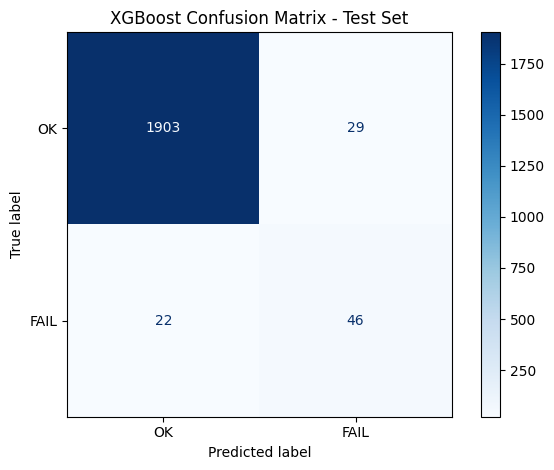


Example failure probabilities (first 8):
[0.5289 0.     0.0008 0.     0.0015 0.     0.0266 0.    ]

True failure rate in test: 0.0340
Predicted failure rate: 0.0375


In [12]:
# ── CELL 7: Model Evaluation on Test Set + Confusion Matrix ──────────────────────

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import numpy as np

print("=== MODEL EVALUATION (Cell 7) ===")

# 1. Debug: Show shape and first few column names of X_test
print(f"X_test shape: {X_test.shape}")
print("X_test columns (first 10):")
print(X_test.columns.tolist()[:10])

print("\nBest model expected feature names (from training):")
print(best_model.feature_names_in_[:10])  # This is what XGBoost remembers

# 2. Critical: Align X_test column names to exactly match training
#    → Use the names the model was trained on

expected_columns = best_model.feature_names_in_

# If columns don't match, re-order and rename X_test to match
if list(X_test.columns) != list(expected_columns):
    print("\nWARNING: Column mismatch detected → fixing now...")
    
    # Option A: Rename X_test columns to match training (recommended)
    X_test_aligned = X_test.copy()
    X_test_aligned.columns = expected_columns
    
    # Option B: If names are completely different → re-order by matching
    # (uncomment if Option A fails)
    # X_test_aligned = X_test[expected_columns]
    
    print("Aligned X_test columns:", X_test_aligned.columns.tolist()[:10])
else:
    print("Columns already match → good.")
    X_test_aligned = X_test

# 3. Make prediction using aligned data
y_pred = best_model.predict(X_test_aligned)

# 4. Print classification report
print("\nClassification Report (XGBoost on Test Set):")
print(classification_report(y_test, y_pred, target_names=['OK', 'FAIL'], digits=4))

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['OK', 'FAIL'])
disp.plot(cmap='Blues', values_format='d')
plt.title('XGBoost Confusion Matrix - Test Set')
plt.tight_layout()

# Save plot
plt.savefig('../reports/confusion_matrix_xgb_test.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. Optional: Failure probability (for later SHAP or API)
y_pred_proba = best_model.predict_proba(X_test_aligned)[:, 1]
print("\nExample failure probabilities (first 8):")
print(y_pred_proba[:8].round(4))

# 7. Quick sanity check
print(f"\nTrue failure rate in test: {y_test.mean():.4f}")
print(f"Predicted failure rate: {(y_pred == 1).mean():.4f}")

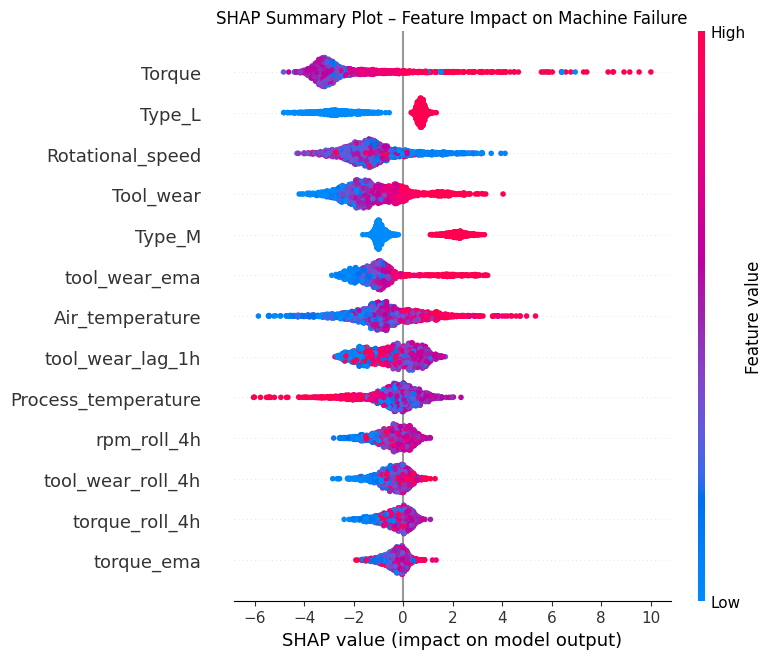

In [13]:
# SHAP Explainer
explainer = shap.TreeExplainer(best_model)

# Use aligned test set
shap_values = explainer.shap_values(X_test_aligned)

# Summary plot with correct feature names
shap.summary_plot(shap_values, X_test_aligned, show=False)
plt.title("SHAP Summary Plot – Feature Impact on Machine Failure")
plt.tight_layout()
plt.savefig('../reports/shap_summary_week3.png', dpi=300)
plt.show()

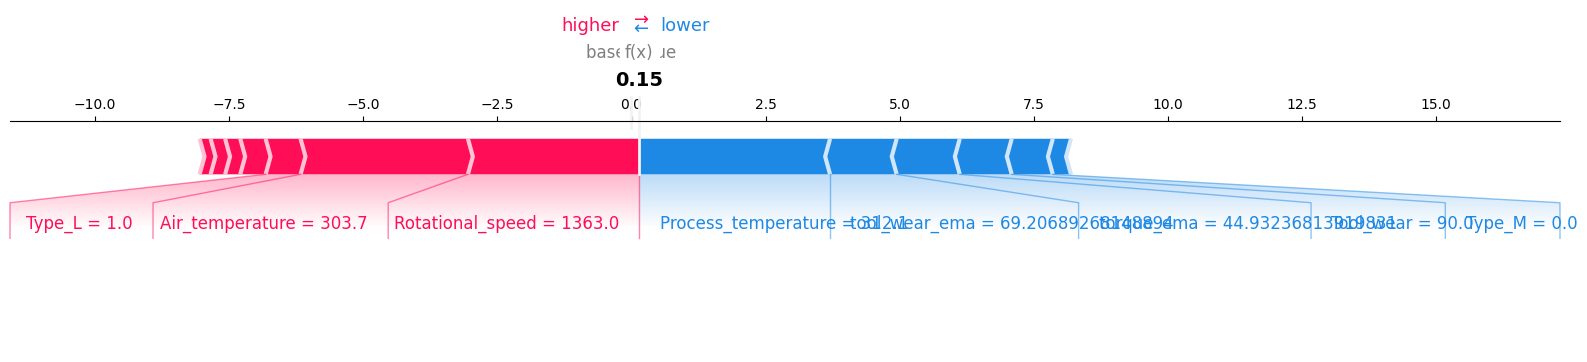

In [14]:
# Example force plot
idx = y_test[y_test == 1].index[0]   # one failure case
shap.force_plot(explainer.expected_value, 
                shap_values[X_test_aligned.index.get_loc(idx)], 
                X_test_aligned.loc[idx], 
                matplotlib=True)

In [15]:
import shap
import matplotlib.pyplot as plt

print("Creating SHAP explainer...")
explainer = shap.TreeExplainer(best_model)

print("Computing SHAP values on test set...")
# Use the aligned X_test you created in previous cell
shap_values = explainer.shap_values(X_test_aligned)

print(f"SHAP values computed → shape: {shap_values.shape}")

Creating SHAP explainer...
Computing SHAP values on test set...
SHAP values computed → shape: (2000, 13)


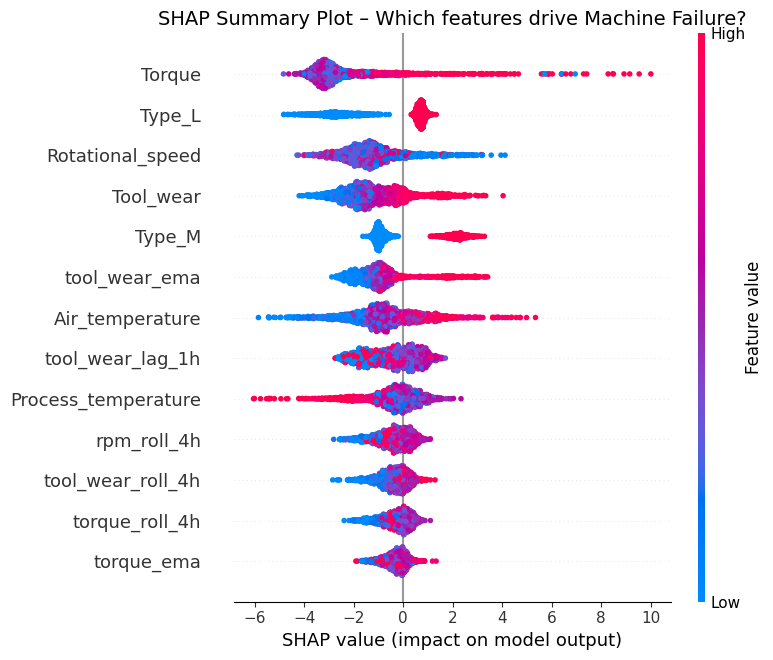

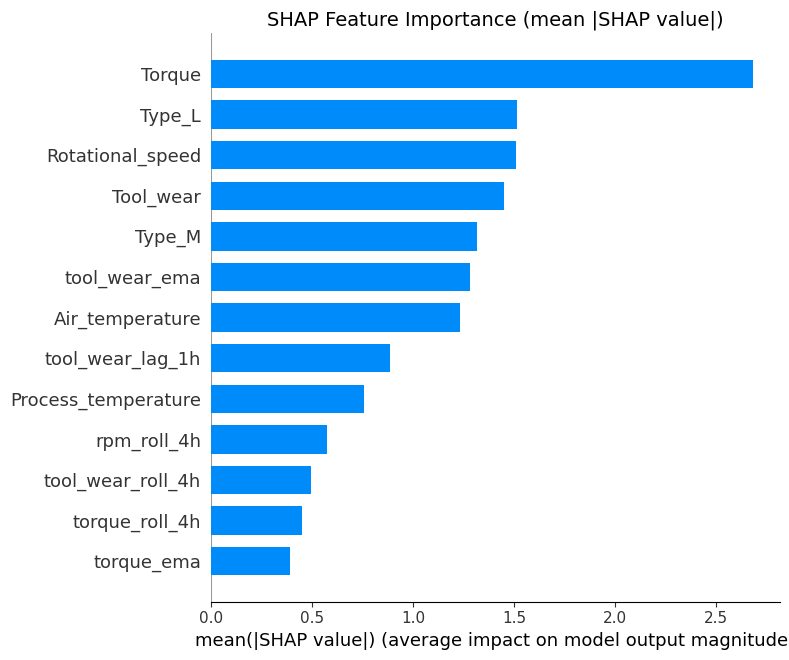

In [16]:
# 1. Beeswarm plot (shows direction + magnitude)
plt.figure(figsize=(14, 10))
shap.summary_plot(shap_values, X_test_aligned, show=False)
plt.title("SHAP Summary Plot – Which features drive Machine Failure?", fontsize=14)
plt.tight_layout()
plt.savefig('../reports/shap_summary_beeswarm_week3.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Bar plot (just importance ranking)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_aligned, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (mean |SHAP value|)", fontsize=14)
plt.tight_layout()
plt.savefig('../reports/shap_summary_bar_week3.png', dpi=300, bbox_inches='tight')
plt.show()

Found 4 failure cases in test set

Force plot 1 – Instance 4851 (true label = FAIL)


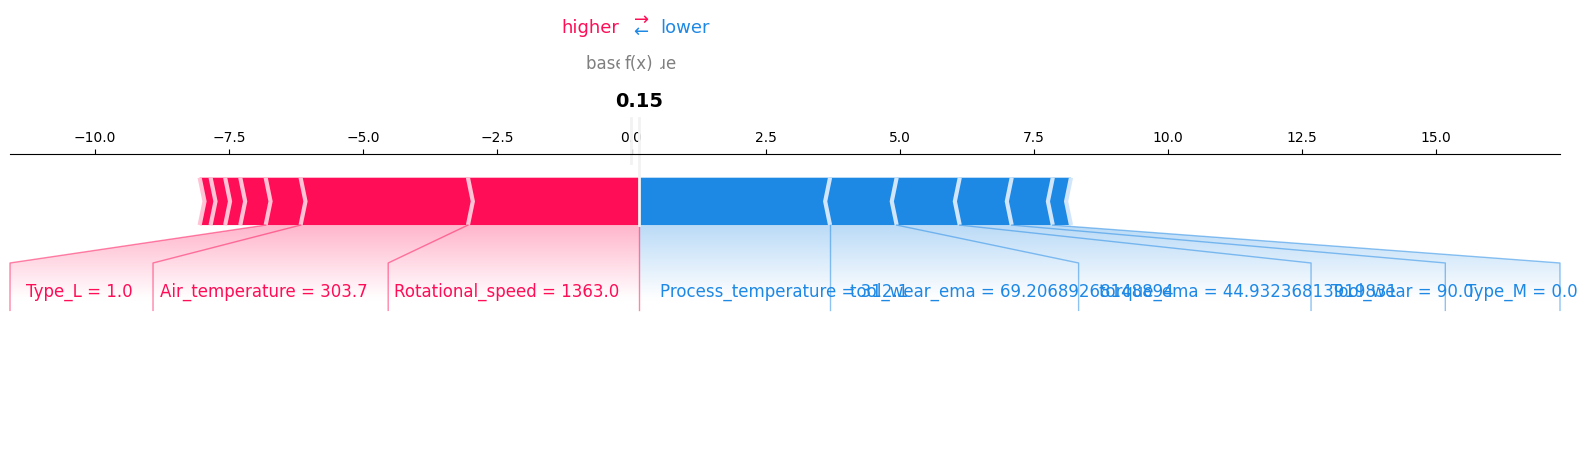


Force plot 2 – Instance 1391 (true label = FAIL)


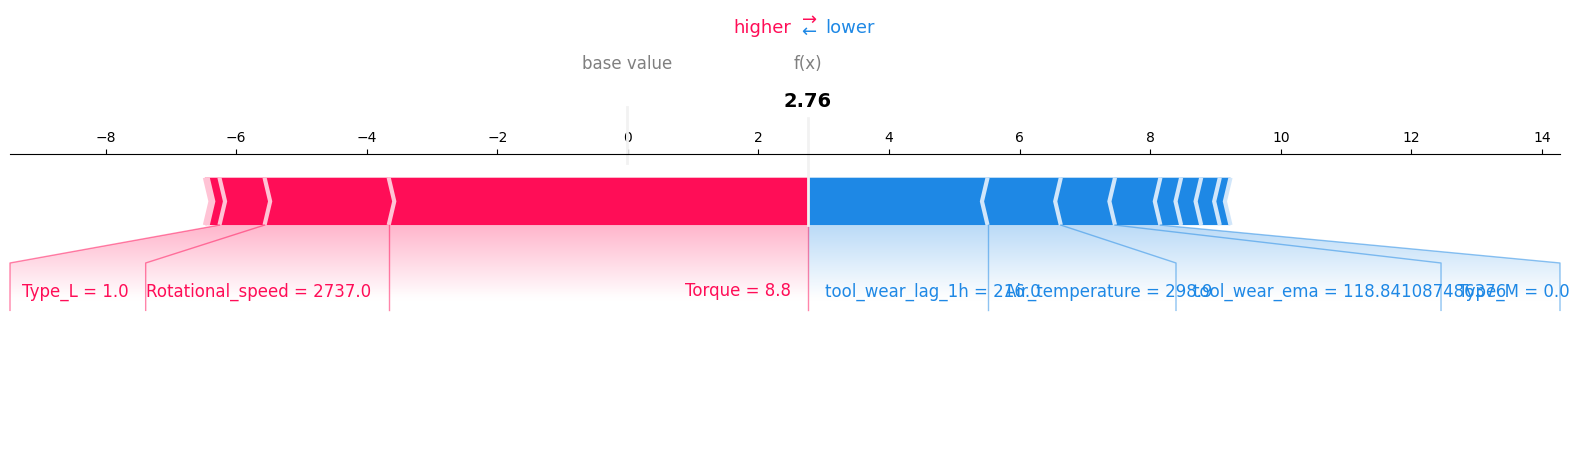


Force plot 3 – Instance 4495 (true label = FAIL)


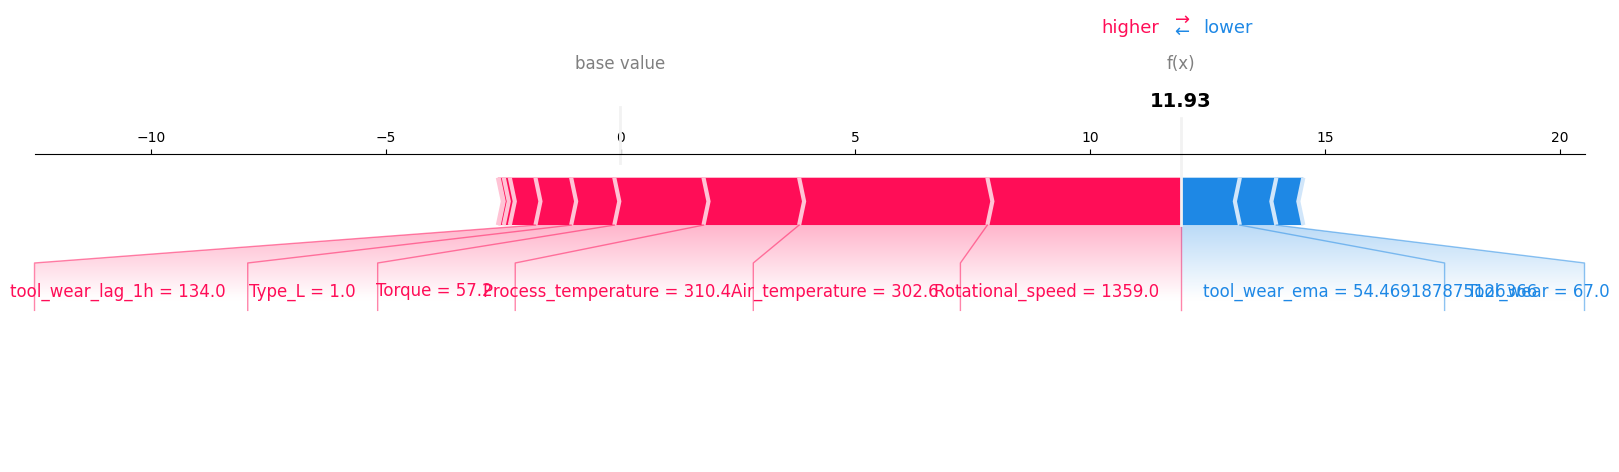


Force plot 4 – Instance 8582 (true label = FAIL)


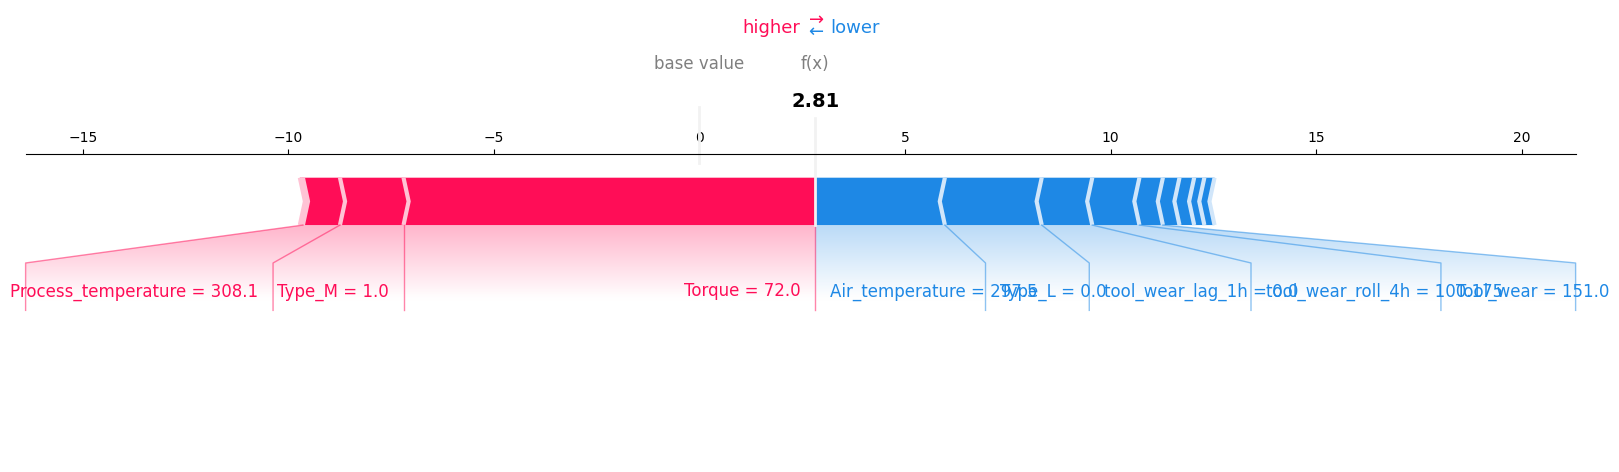


Force plot – Normal case 2997 (true label = OK)


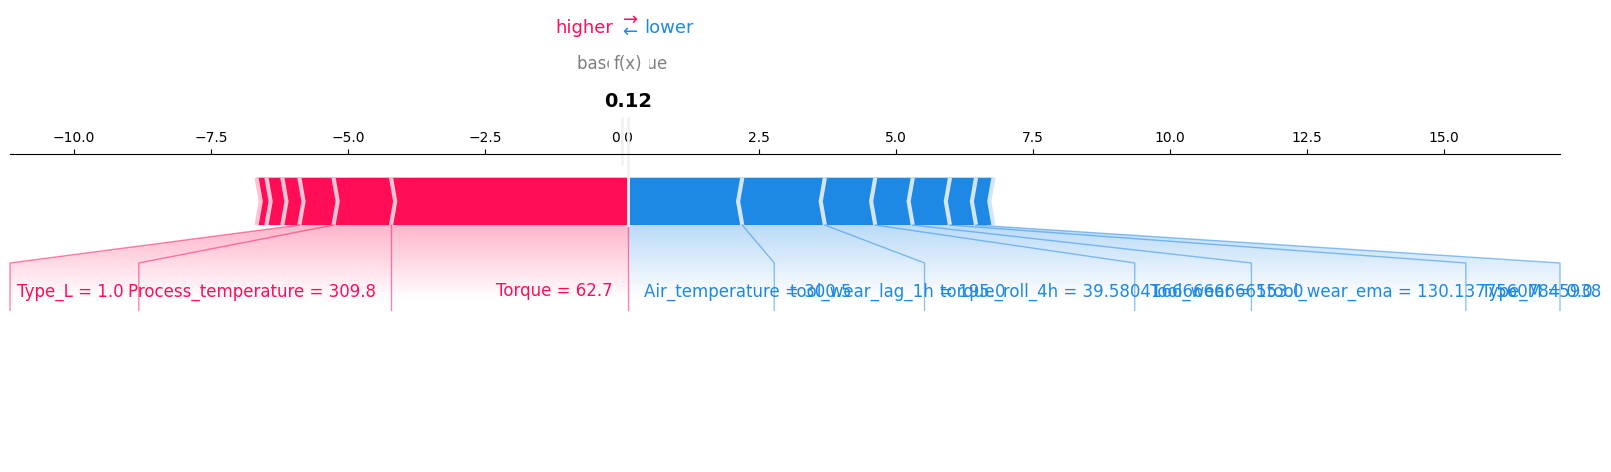

<Figure size 640x480 with 0 Axes>

In [17]:
# Find some real failure cases in test set
failure_indices = y_test[y_test == 1].index[:4]  # first 4 failures (if exist)

print(f"Found {len(failure_indices)} failure cases in test set")

for i, idx in enumerate(failure_indices):
    print(f"\nForce plot {i+1} – Instance {idx} (true label = FAIL)")
    
    # Use aligned data
    row = X_test_aligned.loc[idx]
    shap_val = shap_values[X_test_aligned.index.get_loc(idx)]
    
    shap.force_plot(
        explainer.expected_value,
        shap_val,
        row,
        matplotlib=True,
        figsize=(20, 4),
        show=False
    )
    plt.savefig(f'../reports/force_plot_failure_{idx}.png', dpi=150, bbox_inches='tight')
    plt.show()

# One normal example (optional)
if not y_test[y_test == 0].empty:
    safe_idx = y_test[y_test == 0].index[0]
    print(f"\nForce plot – Normal case {safe_idx} (true label = OK)")
    shap.force_plot(
        explainer.expected_value,
        shap_values[X_test_aligned.index.get_loc(safe_idx)],
        X_test_aligned.loc[safe_idx],
        matplotlib=True,
        figsize=(20, 4)
    )
    plt.savefig('../reports/force_plot_normal_example.png', dpi=150, bbox_inches='tight')
    plt.show()

In [18]:
print("=== Week 3 – Physical Validation Checklist ===")
print("Look at the SHAP summary plot and answer:")

print("\n1. Is 'Tool_wear' (or tool_wear_roll_4h, tool_wear_ema) among the top features?")
print("   → Expected: YES – tool wear is physically the strongest predictor")

print("\n2. For high values of Tool wear / Torque / Temperature → do they push probability UP (red on right in beeswarm)?")
print("   → Expected: YES – higher wear/torque/heat increases failure risk")

print("\n3. Does high Rotational_speed push DOWN (blue on left)?")
print("   → Expected: Often yes – higher stable RPM can mean less stress")

print("\nTop 10 most important features according to SHAP:")
importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test_aligned.columns)
print(importance.sort_values(ascending=False).head(10))

print("\nYour conclusion (write 2-3 sentences):")
print("Example:")
print("The model is trustworthy: Tool wear related features dominate and high values strongly increase failure probability.")
print("This aligns with real manufacturing knowledge – excessive tool wear is the primary failure driver.")

=== Week 3 – Physical Validation Checklist ===
Look at the SHAP summary plot and answer:

1. Is 'Tool_wear' (or tool_wear_roll_4h, tool_wear_ema) among the top features?
   → Expected: YES – tool wear is physically the strongest predictor

2. For high values of Tool wear / Torque / Temperature → do they push probability UP (red on right in beeswarm)?
   → Expected: YES – higher wear/torque/heat increases failure risk

3. Does high Rotational_speed push DOWN (blue on left)?
   → Expected: Often yes – higher stable RPM can mean less stress

Top 10 most important features according to SHAP:
Torque                 2.680759
Type_L                 1.515307
Rotational_speed       1.508624
Tool_wear              1.451474
Type_M                 1.315701
tool_wear_ema          1.283732
Air_temperature        1.231824
tool_wear_lag_1h       0.886080
Process_temperature    0.757315
rpm_roll_4h            0.573082
dtype: float32

Your conclusion (write 2-3 sentences):
Example:
The model is trustwor